# Machine Learning Baseline

## Objectives

- Load engineered features
- Prepare feature matrix and target variable
- Train a baseline Random Forest classifier
- Evaluate model performance
- Analyze feature importance

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
stock = pd.read_csv(
    "../data/processed/reliance_features.csv",
    parse_dates=["Date"]
)

stock.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Daily_Return,Log_Return,Trading_Range,Price_Change,Volatility20,MA20,MA50,MA200,EMA20,Target
0,2015-10-21,205.980789,218.296936,222.822876,217.839767,218.411224,14404450,-0.001777,-0.001779,4.983109,-0.114288,0.018993,203.392169,203.055238,206.833089,206.858732,1
1,2015-10-23,206.120972,218.445511,222.422867,215.131058,220.342758,12153422,0.000681,0.000680,7.291809,-1.897247,0.016707,204.623661,202.994663,206.910522,207.962235,0
2,2015-10-26,203.360199,215.519653,220.125595,215.165344,219.874161,10938775,-0.013394,-0.013485,4.960251,-4.354507,0.017261,205.680859,202.888829,206.976011,208.681989,0
3,2015-10-27,202.648392,214.765320,216.753998,214.273865,214.593887,11601798,-0.003500,-0.003506,2.480133,0.171432,0.016713,206.848918,202.873514,207.048814,209.261354,0
4,2015-10-28,202.087601,214.171005,215.988251,212.559494,214.159576,11958727,-0.002767,-0.002771,3.428757,0.011429,0.016686,208.022693,202.889972,207.164078,209.728939,1


In [3]:
features = [
    "Daily_Return",
    "Log_Return",
    "Trading_Range",
    "Price_Change",
    "Volatility20",
    "MA20",
    "MA50",
    "MA200",
    "EMA20"
]

X = stock[features]

y = stock["Target"]

In [4]:
print("Feature Matrix:", X.shape)
print("Target:", y.shape)

Feature Matrix: (2267, 9)
Target: (2267,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    shuffle=False
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (1813, 9)
Testing: (454, 9)


In [6]:
model = RandomForestClassifier(
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [7]:
predictions = model.predict(X_test)

In [8]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", round(accuracy,4))

Accuracy: 0.511


In [9]:
cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

[[175  42]
 [180  57]]


In [10]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.49      0.81      0.61       217
           1       0.58      0.24      0.34       237

    accuracy                           0.51       454
   macro avg       0.53      0.52      0.48       454
weighted avg       0.54      0.51      0.47       454



In [11]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
4,Volatility20,0.127669
2,Trading_Range,0.120730
3,Price_Change,0.119543
0,Daily_Return,0.110198
6,MA50,0.106840
7,MA200,0.105636
1,Log_Return,0.105398
8,EMA20,0.103959
5,MA20,0.100027


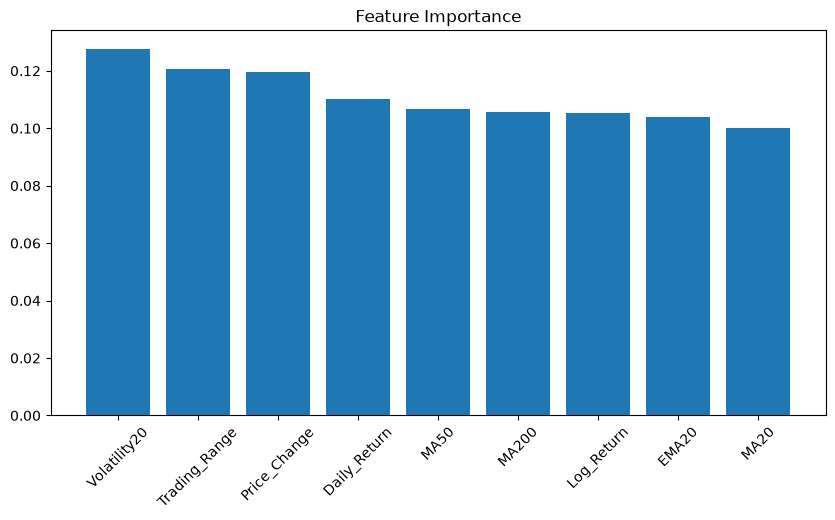

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()

## Conclusion

### Model Performance

- A baseline Random Forest classifier was trained to predict next-day stock price direction.
- The model achieved an accuracy of approximately 50%, which is close to random guessing.
- Feature importance analysis showed that volatility, trading range, and price-based features contributed most to the model.
- This suggests that additional features or more advanced models may be needed to improve predictive performance.